In [ ]:
# Cell 1: Environment Setup and Imports
# This cell installs required packages and imports all necessary libraries

# Install required packages
!pip install numpy pandas scikit-learn torch torchvision torchaudio tqdm matplotlib seaborn joblib dash plotly dash-bootstrap-components

# Core imports
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import hashlib
import time
import copy
import joblib
import os
import warnings
warnings.filterwarnings('ignore')

# Scikit-learn imports
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, roc_auc_score, confusion_matrix

# PyTorch imports
import torch
import torch.nn as nn
import torch.optim as optim
import torch.nn.functional as F
from torch.utils.data import DataLoader, TensorDataset

# Progress bar
from tqdm import tqdm

# Dashboard imports
import dash
from dash import dcc, html, Input, Output, callback
import plotly.graph_objs as go
import plotly.express as px
import dash_bootstrap_components as dbc
import threading

# Google Colab specific
from google.colab import drive
from google.colab.output import eval_js

# Device setup
DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")

# Reproducibility
SEED = 42
np.random.seed(SEED)
torch.manual_seed(SEED)
torch.cuda.manual_seed_all(SEED)

# Federated learning parameters
NUM_ROUNDS = 25
LOCAL_EPOCHS = 5
BATCH_SIZE = 64
LEARNING_RATE = 0.0002

# FedProx coefficient
MU = 0.01

print("=" * 60)
print("ENVIRONMENT INITIALIZED")
print("=" * 60)
print(f"Using device: {DEVICE}")
print(f"Parameters: Rounds={NUM_ROUNDS}, Local Epochs={LOCAL_EPOCHS}, LR={LEARNING_RATE}, MU={MU}")
print("=" * 60)

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 7.2/7.2 MB 55.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 204.0/204.0 kB 14.5 MB/s eta 0:00:00
ENVIRONMENT INITIALIZED
Using device: cpu
Parameters: Rounds=25, Local Epochs=5, LR=0.0002, MU=0.01


In [ ]:
# Cell 2: Mount Google Drive and Load Dataset Paths

# Mount Google Drive
drive.mount('/content/drive')

# Dataset paths
DATASET_PATH = "/content/drive/MyDrive/8th Semester/Major Project - 2"

DATASETS = {
    "BDT_Blockchain": f"{DATASET_PATH}/blockchain_trust_imbalanced.csv",
    "TON_IOT_Net": f"{DATASET_PATH}/ton_iot_test.csv",
    "IEC104_SCADA": f"{DATASET_PATH}/IEC104_Flow_Stats_Balanced.csv"
}

print("\n" + "=" * 60)
print("DATASET LOCATIONS")
print("=" * 60)
for name, path in DATASETS.items():
    print(f"{name:20} -> {path}")
print("=" * 60)

Mounted at /content/drive

DATASET LOCATIONS
BDT_Blockchain       -> /content/drive/MyDrive/8th Semester/Major Project - 2/blockchain_trust_imbalanced.csv
TON_IOT_Net          -> /content/drive/MyDrive/8th Semester/Major Project - 2/ton_iot_test.csv
IEC104_SCADA         -> /content/drive/MyDrive/8th Semester/Major Project - 2/IEC104_Flow_Stats_Balanced.csv


In [ ]:
# Cell 3: Load Datasets with Size Reduction

# Target rows for each dataset (to manage memory)
TARGET_ROWS = {
    "BDT_Blockchain": 50000,
    "TON_IOT_Net": 40000,
    "IEC104_SCADA": None  # Keep all samples
}

datasets = {}

print("\n" + "=" * 60)
print("LOADING DATASETS")
print("=" * 60)

for name, path in DATASETS.items():
    print(f"\nLoading dataset: {name}")
    df = pd.read_csv(path, low_memory=False)
    print(f"  Original shape: {df.shape}")

    target = TARGET_ROWS.get(name)
    if target is not None and len(df) > target:
        df = df.sample(n=target, random_state=SEED)
        print(f"  Reduced shape: {df.shape}")

    datasets[name] = df
    print(f"  Loaded successfully")

print("\n" + "=" * 60)
print("ALL DATASETS LOADED")
print("=" * 60)


LOADING DATASETS

Loading dataset: BDT_Blockchain
  Original shape: (1000000, 19)
  Reduced shape: (50000, 19)
  Loaded successfully

Loading dataset: TON_IOT_Net
  Original shape: (211043, 44)
  Reduced shape: (40000, 44)
  Loaded successfully

Loading dataset: IEC104_SCADA
  Original shape: (425, 84)
  Loaded successfully

ALL DATASETS LOADED



DATASET EXPLORATION

BDT_BLOCKCHAIN
----------------------------------------
  Shape: (50000, 19)
  Columns: ['Tx_Success_Rate', 'Vulnerability_Count', 'External_Calls', 'Unchecked_Returns', 'Safety_Rating']... (19 total)
  Data types:
float64    10
int64       8
object      1
Name: count, dtype: int64
  Missing values: 0

TON_IOT_NET
----------------------------------------
  Shape: (40000, 44)
  Columns: ['src_ip', 'src_port', 'dst_ip', 'dst_port', 'proto']... (44 total)
  Data types:
object     27
int64      16
float64     1
Name: count, dtype: int64
  Missing values: 0

IEC104_SCADA
----------------------------------------
  Shape: (425, 84)
  Columns: ['Flow ID', 'Src IP', 'Src Port', 'Dst IP', 'Dst Port']... (84 total)
  Data types:
float64    71
int64       7
object      6
Name: count, dtype: int64
  Missing values: 20

FIGURE 1: Class Distribution Across Datasets


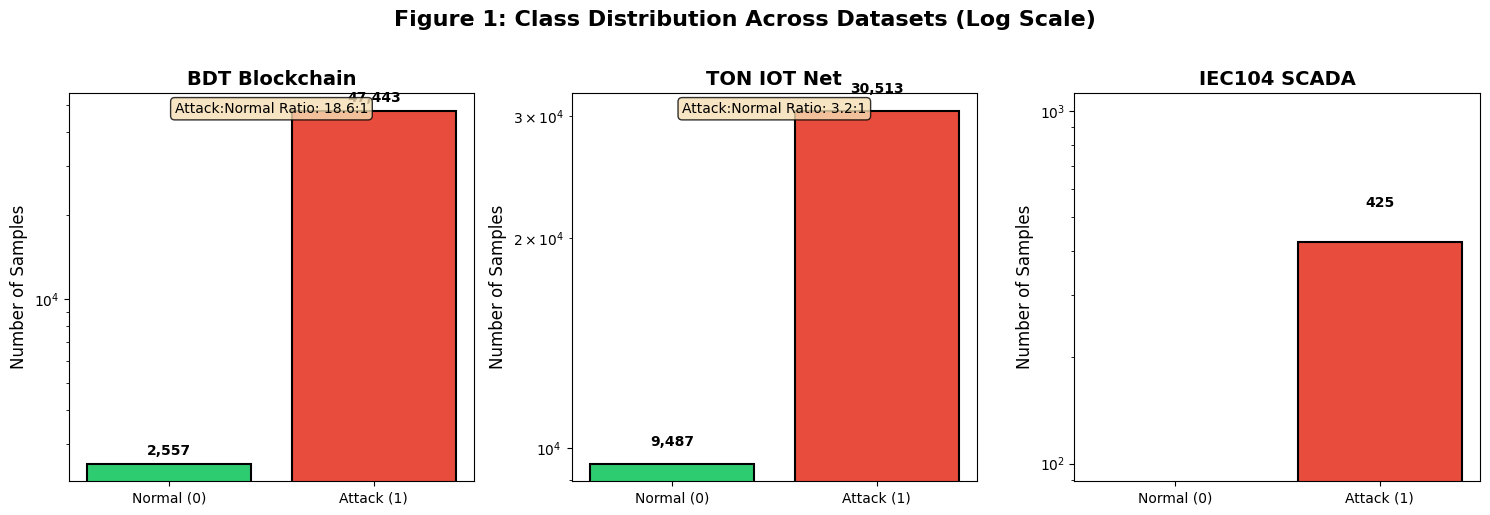


CLASS DISTRIBUTION SUMMARY
BDT_Blockchain      : Normal=2,557, Attack=47,443, Ratio=18.55:1
TON_IOT_Net         : Normal=9,487, Attack=30,513, Ratio=3.22:1
IEC104_SCADA        : Normal=0, Attack=425, Ratio=0.00:1


In [ ]:
# Cell 4: Dataset Exploration and Visualization

print("\n" + "=" * 60)
print("DATASET EXPLORATION")
print("=" * 60)

# Display basic info for each dataset
for name, df in datasets.items():
    print(f"\n{name.upper()}")
    print("-" * 40)
    print(f"  Shape: {df.shape}")
    print(f"  Columns: {list(df.columns)[:5]}... ({len(df.columns)} total)")
    print(f"  Data types:\n{df.dtypes.value_counts()}")

    # Check for missing values
    missing = df.isnull().sum().sum()
    print(f"  Missing values: {missing}")

# Dataset class distribution visualization
print("\n" + "=" * 60)
print("FIGURE 1: Class Distribution Across Datasets")
print("=" * 60)

fig, axes = plt.subplots(1, 3, figsize=(15, 5))

# Dataset class distributions
dataset_distributions = {
    'BDT_Blockchain': {'attack': None, 'normal': None},
    'TON_IOT_Net': {'attack': None, 'normal': None},
    'IEC104_SCADA': {'attack': None, 'normal': None}
}

for idx, (name, df) in enumerate(datasets.items()):
    ax = axes[idx]

    # Determine label column and values
    if name == "BDT_Blockchain":
        label_col = "Trust_Label"
    elif name == "TON_IOT_Net":
        label_col = "label"
    else:  # IEC104_SCADA
        label_col = "Label"

    if label_col in df.columns:
        counts = df[label_col].value_counts().sort_index()
        # Convert to standard format (0=normal, 1=attack)
        if name == "IEC104_SCADA":
            # IEC104 has "normal" and attack types
            normal_count = counts.get('normal', 0) if 'normal' in counts.index else 0
            attack_count = counts.sum() - normal_count
            values = [normal_count, attack_count]
            dataset_distributions[name]['normal'] = normal_count
            dataset_distributions[name]['attack'] = attack_count
        else:
            # BDT and TON have 0 and 1 labels
            normal_count = counts.get(0, 0)
            attack_count = counts.get(1, 0)
            values = [normal_count, attack_count]
            dataset_distributions[name]['normal'] = normal_count
            dataset_distributions[name]['attack'] = attack_count
    else:
        # Fallback if label column not found
        values = [0, 0]
        dataset_distributions[name]['normal'] = 0
        dataset_distributions[name]['attack'] = 0

    categories = ['Normal (0)', 'Attack (1)']
    colors = ['#2ecc71', '#e74c3c']
    bars = ax.bar(categories, values, color=colors, edgecolor='black', linewidth=1.5)
    ax.set_title(name.replace('_', ' '), fontsize=14, fontweight='bold')
    ax.set_ylabel('Number of Samples', fontsize=12)
    ax.set_yscale('log')

    # Add value labels on bars
    for bar, val in zip(bars, values):
        if val > 0:
            ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + max(100, val*0.05),
                    f'{val:,}', ha='center', va='bottom', fontsize=10, fontweight='bold')

    # Add imbalance ratio
    if values[0] > 0:
        ratio = values[1] / values[0]
        ax.text(0.5, 0.95, f'Attack:Normal Ratio: {ratio:.1f}:1',
                transform=ax.transAxes, ha='center', fontsize=10,
                bbox=dict(boxstyle='round', facecolor='wheat', alpha=0.8))

plt.suptitle('Figure 1: Class Distribution Across Datasets (Log Scale)',
             fontsize=16, fontweight='bold', y=1.02)
plt.tight_layout()
plt.show()

# Print summary
print("\n" + "=" * 60)
print("CLASS DISTRIBUTION SUMMARY")
print("=" * 60)
for name, dist in dataset_distributions.items():
    print(f"{name:20}: Normal={dist['normal']:,}, Attack={dist['attack']:,}, Ratio={dist['attack']/dist['normal'] if dist['normal'] > 0 else 0:.2f}:1")

In [ ]:
# Cell 5: Dataset Cleaning and Label Standardization

clean_datasets = {}

print("\n" + "=" * 60)
print("DATASET CLEANING AND STANDARDIZATION")
print("=" * 60)

for name, df in datasets.items():
    print(f"\nProcessing: {name}")
    df = df.copy()

    # Blockchain dataset
    if name == "BDT_Blockchain":
        if "Attack_Type" in df.columns:
            df.drop(columns=["Attack_Type"], inplace=True)
        if "Trust_Label" in df.columns:
            df.rename(columns={"Trust_Label": "target"}, inplace=True)

    # TON IoT dataset
    elif name == "TON_IOT_Net":
        drop_cols = [
            "src_ip", "dst_ip", "service",
            "http_user_agent", "http_orig_mime_types", "http_resp_mime_types"
        ]
        df.drop(columns=[c for c in drop_cols if c in df.columns], inplace=True)
        if "label" in df.columns:
            df.rename(columns={"label": "target"}, inplace=True)

    # SCADA dataset
    elif name == "IEC104_SCADA":
        drop_cols = ["Flow ID", "Src IP", "Dst IP", "Timestamp"]
        df.drop(columns=[c for c in drop_cols if c in df.columns], inplace=True)
        if "Label" in df.columns:
            df.rename(columns={"Label": "target"}, inplace=True)
        df["target"] = df["target"].apply(
            lambda x: 0 if "normal" in str(x).lower() else 1
        )

    # Convert categorical features
    for col in df.columns:
        if df[col].dtype == "object" and col != "target":
            df[col] = pd.factorize(df[col])[0]

    # Handle missing values
    df.replace([np.inf, -np.inf], np.nan, inplace=True)
    df.dropna(inplace=True)

    clean_datasets[name] = df

    print(f"  Final shape: {df.shape}")
    print(f"  Target distribution:")
    print(df["target"].value_counts())

print("\n" + "=" * 60)
print("DATASET CLEANING COMPLETE")
print("=" * 60)


DATASET CLEANING AND STANDARDIZATION

Processing: BDT_Blockchain
  Final shape: (50000, 18)
  Target distribution:
target
1    47443
0     2557
Name: count, dtype: int64

Processing: TON_IOT_Net
  Final shape: (40000, 38)
  Target distribution:
target
1    30513
0     9487
Name: count, dtype: int64

Processing: IEC104_SCADA
  Final shape: (424, 80)
  Target distribution:
target
1    351
0     73
Name: count, dtype: int64

DATASET CLEANING COMPLETE


In [ ]:
# Cell 6: Feature Scaling and Save Scalers

scaled_datasets = {}
scalers = {}

print("\n" + "=" * 60)
print("FEATURE SCALING")
print("=" * 60)

for name, df in clean_datasets.items():
    print(f"\nScaling dataset: {name}")
    X = df.drop(columns=["target"])
    y = df["target"]

    scaler = StandardScaler()
    X_scaled = scaler.fit_transform(X)

    scaled_df = pd.DataFrame(X_scaled, columns=X.columns)
    scaled_df["target"] = y.values

    scaled_datasets[name] = scaled_df
    scalers[name] = scaler

    print(f"  Scaled shape: {scaled_df.shape}")

    # Save scaler for later deployment
    joblib.dump(scaler, f"scaler_{name}.pkl")
    print(f"  Saved scaler for {name}")

print("\n" + "=" * 60)
print("FEATURE SCALING COMPLETE")
print("=" * 60)


FEATURE SCALING

Scaling dataset: BDT_Blockchain
  Scaled shape: (50000, 18)
  Saved scaler for BDT_Blockchain

Scaling dataset: TON_IOT_Net
  Scaled shape: (40000, 38)
  Saved scaler for TON_IOT_Net

Scaling dataset: IEC104_SCADA
  Scaled shape: (424, 80)
  Saved scaler for IEC104_SCADA

FEATURE SCALING COMPLETE



FIGURE 2: Feature Dimensionality Comparison


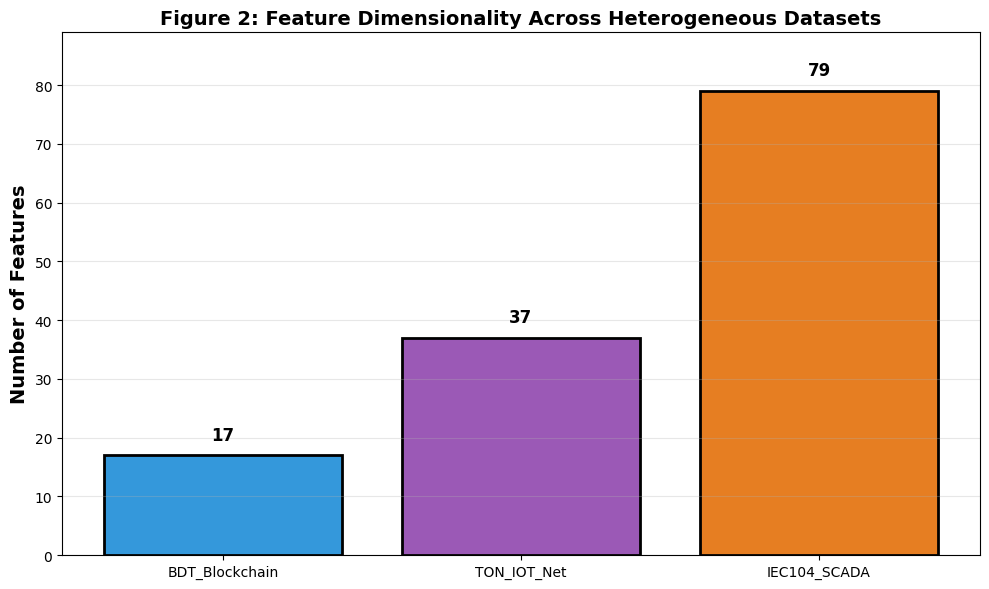


Feature Dimensionality Summary:
  BDT_Blockchain      : 17 features
  TON_IOT_Net         : 37 features
  IEC104_SCADA        : 79 features


In [ ]:
# Cell 7: Feature Dimensionality Comparison

print("\n" + "=" * 60)
print("FIGURE 2: Feature Dimensionality Comparison")
print("=" * 60)

feature_dims = {}
for name, df in scaled_datasets.items():
    feature_dims[name] = df.shape[1] - 1  # Subtract target column

fig, ax = plt.subplots(figsize=(10, 6))
colors = ['#3498db', '#9b59b6', '#e67e22']
bars = ax.bar(feature_dims.keys(), feature_dims.values(), color=colors,
              edgecolor='black', linewidth=2)
ax.set_ylabel('Number of Features', fontsize=14, fontweight='bold')
ax.set_title('Figure 2: Feature Dimensionality Across Heterogeneous Datasets',
             fontsize=14, fontweight='bold')
ax.set_ylim(0, max(feature_dims.values()) + 10)

# Add value labels
for bar, val in zip(bars, feature_dims.values()):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 2,
            str(val), ha='center', va='bottom', fontsize=12, fontweight='bold')

ax.grid(axis='y', alpha=0.3)
plt.tight_layout()
plt.show()

print("\nFeature Dimensionality Summary:")
for name, dim in feature_dims.items():
    print(f"  {name:20}: {dim} features")

In [ ]:
# Cell 8: Create Federated Clients

clients = {}

print("\n" + "=" * 60)
print("FEDERATED CLIENT PREPARATION")
print("=" * 60)

for name, df in scaled_datasets.items():
    X = df.drop(columns=["target"])
    y = df["target"]
    clients[name] = {"X": X, "y": y}
    print(f"\n{name} client prepared:")
    print(f"  Feature shape: {X.shape}")
    print(f"  Label distribution:")
    print(y.value_counts())
    print("-" * 40)


FEDERATED CLIENT PREPARATION

BDT_Blockchain client prepared:
  Feature shape: (50000, 17)
  Label distribution:
target
1    47443
0     2557
Name: count, dtype: int64
----------------------------------------

TON_IOT_Net client prepared:
  Feature shape: (40000, 37)
  Label distribution:
target
1    30513
0     9487
Name: count, dtype: int64
----------------------------------------

IEC104_SCADA client prepared:
  Feature shape: (424, 79)
  Label distribution:
target
1    351
0     73
Name: count, dtype: int64
----------------------------------------


In [ ]:
# Cell 9: Train/Test Split for Each Client

client_splits = {}

print("\n" + "=" * 60)
print("TRAIN/TEST SPLIT")
print("=" * 60)

for name, data in clients.items():
    X = data["X"]
    y = data["y"]

    X_train, X_test, y_train, y_test = train_test_split(
        X, y, test_size=0.2, random_state=SEED, stratify=y
    )

    client_splits[name] = {
        "X_train": X_train,
        "X_test": X_test,
        "y_train": y_train,
        "y_test": y_test
    }

    print(f"\n{name} split complete:")
    print(f"  Train shape: {X_train.shape}")
    print(f"  Test shape: {X_test.shape}")
    print("-" * 40)


TRAIN/TEST SPLIT

BDT_Blockchain split complete:
  Train shape: (40000, 17)
  Test shape: (10000, 17)
----------------------------------------

TON_IOT_Net split complete:
  Train shape: (32000, 37)
  Test shape: (8000, 37)
----------------------------------------

IEC104_SCADA split complete:
  Train shape: (339, 79)
  Test shape: (85, 79)
----------------------------------------


In [ ]:
# Cell 10: Data Preparation for PyTorch

client_loaders = {}
client_feature_dims = {}

print("\n" + "=" * 60)
print("PYTORCH DATA PREPARATION")
print("=" * 60)

for name, data in client_splits.items():
    X_train = data["X_train"].values
    X_test = data["X_test"].values
    y_train = data["y_train"].values
    y_test = data["y_test"].values

    # Convert to tensors
    X_train_tensor = torch.tensor(X_train, dtype=torch.float32)
    y_train_tensor = torch.tensor(y_train, dtype=torch.long)
    X_test_tensor = torch.tensor(X_test, dtype=torch.float32)
    y_test_tensor = torch.tensor(y_test, dtype=torch.long)

    train_dataset = TensorDataset(X_train_tensor, y_train_tensor)
    test_dataset = TensorDataset(X_test_tensor, y_test_tensor)

    train_loader = DataLoader(train_dataset, batch_size=BATCH_SIZE, shuffle=True)
    test_loader = DataLoader(test_dataset, batch_size=BATCH_SIZE, shuffle=False)

    client_loaders[name] = {
        "train_loader": train_loader,
        "test_loader": test_loader,
        "input_dim": X_train.shape[1]
    }
    client_feature_dims[name] = X_train.shape[1]

    print(f"{name}: {X_train.shape[1]} features, Train={len(train_dataset)}, Test={len(test_dataset)}")

print("\n" + "=" * 60)
print("DATA PREPARATION COMPLETE")
print("=" * 60)


PYTORCH DATA PREPARATION
BDT_Blockchain: 17 features, Train=40000, Test=10000
TON_IOT_Net: 37 features, Train=32000, Test=8000
IEC104_SCADA: 79 features, Train=339, Test=85

DATA PREPARATION COMPLETE


In [ ]:
# Cell 11: Model Definitions

print("\n" + "=" * 60)
print("MODEL DEFINITIONS")
print("=" * 60)

# 1. Prototype model (used for centralized baseline)
class FLModelWithPrototypes(nn.Module):
    def __init__(self, input_dim, num_classes=2, prototype_dim=32):
        super().__init__()
        self.feature_extractor = nn.Sequential(
            nn.Linear(input_dim, 128),
            nn.BatchNorm1d(128),
            nn.ReLU(),
            nn.Dropout(0.3),
            nn.Linear(128, 64),
            nn.BatchNorm1d(64),
            nn.ReLU(),
            nn.Dropout(0.3),
            nn.Linear(64, prototype_dim),
        )
        self.prototypes = nn.Parameter(torch.randn(num_classes, prototype_dim) * 0.1)
        self.prototype_dim = prototype_dim
        self.num_classes = num_classes

    def forward(self, x):
        features = self.feature_extractor(x)
        distances = torch.cdist(features, self.prototypes, p=2)
        logits = -distances
        return logits

# 2. Projection model (for federated learning with per-client projections)
class FLModelWithProjections(nn.Module):
    def __init__(self, client_feature_dims, shared_dim=32, num_classes=2, prototype_dim=32):
        super().__init__()
        # Separate input projections for each client
        self.projections = nn.ModuleDict({
            name: nn.Linear(dim, shared_dim) for name, dim in client_feature_dims.items()
        })

        # Shared feature extractor
        self.feature_extractor = nn.Sequential(
            nn.Linear(shared_dim, 128),
            nn.BatchNorm1d(128),
            nn.ReLU(),
            nn.Dropout(0.3),
            nn.Linear(128, 64),
            nn.BatchNorm1d(64),
            nn.ReLU(),
            nn.Dropout(0.3),
            nn.Linear(64, prototype_dim),
        )

        # Prototypes (learnable)
        self.prototypes = nn.Parameter(torch.randn(num_classes, prototype_dim) * 0.1)
        self.prototype_dim = prototype_dim
        self.num_classes = num_classes

    def forward(self, x, client_name):
        x = self.projections[client_name](x)
        features = self.feature_extractor(x)
        distances = torch.cdist(features, self.prototypes, p=2)
        logits = -distances
        return logits

print("Models defined:")
print("  - FLModelWithPrototypes: For centralized baseline")
print("  - FLModelWithProjections: For federated learning with per-client projections")


MODEL DEFINITIONS
Models defined:
  - FLModelWithPrototypes: For centralized baseline
  - FLModelWithProjections: For federated learning with per-client projections



CENTRALIZED TRAINING (BASELINE)
Padding all data to 79 features for centralized training.
Combined dataset shape: (72339, 79)
Class distribution: [ 9694 62645]

Training Centralized Model...
----------------------------------------


Epoch 1/15: 100%|██████████| 1131/1131 [00:10<00:00, 104.42it/s, loss=0.0803]


Epoch 1/15 completed - Avg Loss: 0.2710


Epoch 2/15: 100%|██████████| 1131/1131 [00:08<00:00, 132.89it/s, loss=0.1428]


Epoch 2/15 completed - Avg Loss: 0.0796


...

Epoch 13/15 completed - Avg Loss: 0.0182


Epoch 14/15: 100%|██████████| 1131/1131 [00:08<00:00, 140.05it/s, loss=0.0074]


Epoch 14/15 completed - Avg Loss: 0.0175


Epoch 15/15: 100%|██████████| 1131/1131 [00:08<00:00, 128.64it/s, loss=0.0012]


Epoch 15/15 completed - Avg Loss: 0.0168

FIGURE 3: Centralized Training Loss Curve


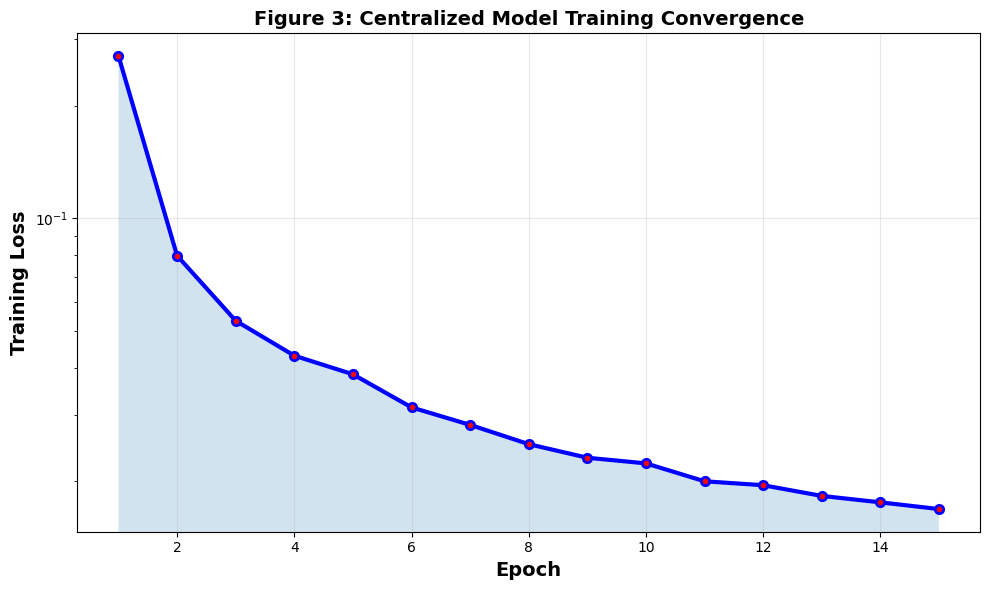


CENTRALIZED MODEL EVALUATION
BDT_Blockchain      : Accuracy = 0.9965
TON_IOT_Net         : Accuracy = 0.9985
IEC104_SCADA        : Accuracy = 1.0000

Average Centralized Accuracy: 0.9983

✅ Centralized model saved to /content/drive/MyDrive/8th Semester/Major Project - 2/centralized_model.pth


In [ ]:
# Cell 12: Centralized Training (Baseline)

print("\n" + "=" * 60)
print("CENTRALIZED TRAINING (BASELINE)")
print("=" * 60)

# Determine maximum feature dimension for padding
max_features = max(client_loaders[name]["input_dim"] for name in client_loaders.keys())
print(f"Padding all data to {max_features} features for centralized training.")

# Combine all training data with padding
all_X_train = []
all_y_train = []

for name, data in client_splits.items():
    X_train = data["X_train"].values
    y_train = data["y_train"].values

    if X_train.shape[1] < max_features:
        padding = np.zeros((X_train.shape[0], max_features - X_train.shape[1]))
        X_train = np.hstack((X_train, padding))

    all_X_train.append(X_train)
    all_y_train.append(y_train)

all_X_train = np.vstack(all_X_train)
all_y_train = np.concatenate(all_y_train)

print(f"Combined dataset shape: {all_X_train.shape}")
print(f"Class distribution: {np.bincount(all_y_train)}")

# Convert to tensors
X_train_tensor = torch.tensor(all_X_train, dtype=torch.float32)
y_train_tensor = torch.tensor(all_y_train, dtype=torch.long)

train_dataset = TensorDataset(X_train_tensor, y_train_tensor)
train_loader = DataLoader(train_dataset, batch_size=BATCH_SIZE, shuffle=True)

# Initialize model
central_model = FLModelWithPrototypes(input_dim=max_features).to(DEVICE)

criterion = nn.CrossEntropyLoss()
optimizer = optim.Adam(central_model.parameters(), lr=LEARNING_RATE)

total_epochs = LOCAL_EPOCHS * 3  # 15 epochs
epoch_losses = []

print("\nTraining Centralized Model...")
print("-" * 40)

for epoch in range(total_epochs):
    epoch_loss = 0
    progress_bar = tqdm(train_loader, desc=f"Epoch {epoch+1}/{total_epochs}", position=0, leave=True)

    for X_batch, y_batch in progress_bar:
        X_batch = X_batch.to(DEVICE)
        y_batch = y_batch.to(DEVICE)

        optimizer.zero_grad()
        outputs = central_model(X_batch)
        loss = criterion(outputs, y_batch)
        loss.backward()
        optimizer.step()

        epoch_loss += loss.item()
        progress_bar.set_postfix({'loss': f'{loss.item():.4f}'})

    avg_loss = epoch_loss / len(train_loader)
    epoch_losses.append(avg_loss)
    print(f"Epoch {epoch+1}/{total_epochs} completed - Avg Loss: {avg_loss:.4f}")

# Plot training loss curve
print("\n" + "=" * 60)
print("FIGURE 3: Centralized Training Loss Curve")
print("=" * 60)

fig, ax = plt.subplots(figsize=(10, 6))
ax.plot(range(1, total_epochs + 1), epoch_losses, 'b-', linewidth=3, marker='o', markersize=6,
        markerfacecolor='red', markeredgewidth=2)
ax.fill_between(range(1, total_epochs + 1), epoch_losses, alpha=0.2)
ax.set_xlabel('Epoch', fontsize=14, fontweight='bold')
ax.set_ylabel('Training Loss', fontsize=14, fontweight='bold')
ax.set_title('Figure 3: Centralized Model Training Convergence', fontsize=14, fontweight='bold')
ax.grid(True, alpha=0.3)
ax.set_yscale('log')
plt.tight_layout()
plt.show()

# Evaluation per dataset
central_model.eval()
centralized_results = {}

print("\n" + "=" * 60)
print("CENTRALIZED MODEL EVALUATION")
print("=" * 60)

for name, loaders in client_loaders.items():
    test_loader = loaders["test_loader"]
    preds, labels = [], []
    with torch.no_grad():
        for X_batch, y_batch in test_loader:
            X_batch = X_batch.to(DEVICE)
            # Pad to max_features
            if X_batch.shape[1] < max_features:
                pad = torch.zeros(X_batch.shape[0], max_features - X_batch.shape[1], device=DEVICE)
                X_batch = torch.cat([X_batch, pad], dim=1)
            outputs = central_model(X_batch)
            preds.extend(torch.argmax(outputs, dim=1).cpu().numpy())
            labels.extend(y_batch.numpy())
    acc = accuracy_score(labels, preds)
    centralized_results[name] = acc
    print(f"{name:20}: Accuracy = {acc:.4f}")

print(f"\nAverage Centralized Accuracy: {np.mean(list(centralized_results.values())):.4f}")

# Save centralized model
drive_path = "/content/drive/MyDrive/8th Semester/Major Project - 2/"
os.makedirs(drive_path, exist_ok=True)

torch.save({
    'model_state_dict': central_model.state_dict(),
    'max_features': max_features,
    'epoch_losses': epoch_losses,
}, drive_path + 'centralized_model.pth')

print(f"\n✅ Centralized model saved to {drive_path}centralized_model.pth")


CENTRALIZED MODEL – DETAILED METRICS
✅ Centralized model loaded (max_features: 79)

BDT_Blockchain:
  Accuracy    : 0.9965
  Precision   : 0.9965
  Recall      : 0.9965
  F1          : 0.9964
  ROC‑AUC     : 0.9958

TON_IOT_Net:
  Accuracy    : 0.9985
  Precision   : 0.9985
  Recall      : 0.9985
  F1          : 0.9985
  ROC‑AUC     : 1.0000

IEC104_SCADA:
  Accuracy    : 1.0000
  Precision   : 1.0000
  Recall      : 1.0000
  F1          : 1.0000
  ROC‑AUC     : 1.0000

AVERAGE CENTRALIZED METRICS
Accuracy    : 0.9983
Precision   : 0.9983
Recall      : 0.9983
F1          : 0.9983
ROC‑AUC     : 0.9986


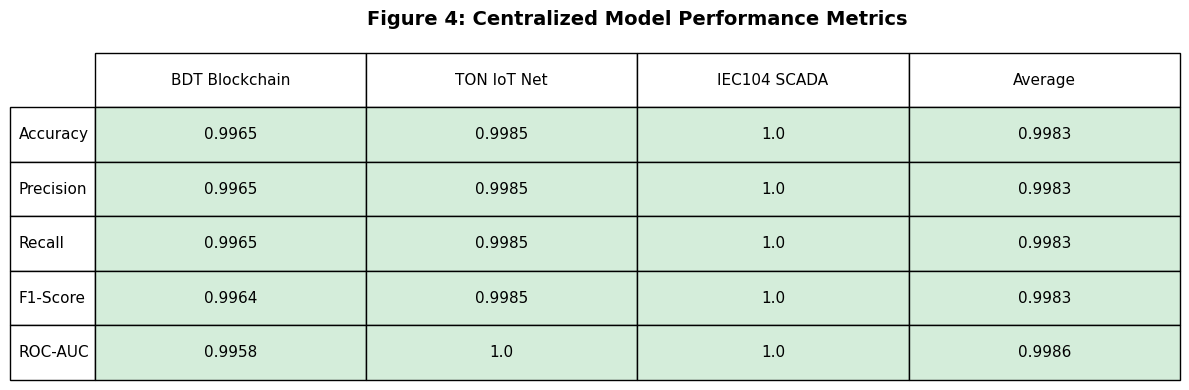

In [ ]:
# Cell 13: Centralized Model Detailed Metrics

print("\n" + "=" * 60)
print("CENTRALIZED MODEL – DETAILED METRICS")
print("=" * 60)

# Load centralized model (if needed)
checkpoint = torch.load(drive_path + 'centralized_model.pth', map_location=DEVICE)
central_model = FLModelWithPrototypes(input_dim=checkpoint['max_features']).to(DEVICE)
central_model.load_state_dict(checkpoint['model_state_dict'])
central_model.eval()
print(f"✅ Centralized model loaded (max_features: {checkpoint['max_features']})")

central_metrics = {}

for name, loaders in client_loaders.items():
    test_loader = loaders["test_loader"]
    all_preds = []
    all_labels = []
    all_probs = []

    with torch.no_grad():
        for X_batch, y_batch in test_loader:
            X_batch = X_batch.to(DEVICE)
            if X_batch.shape[1] < max_features:
                pad = torch.zeros(X_batch.shape[0], max_features - X_batch.shape[1], device=DEVICE)
                X_batch = torch.cat([X_batch, pad], dim=1)
            outputs = central_model(X_batch)
            probs = torch.softmax(outputs, dim=1)[:, 1]
            preds = torch.argmax(outputs, dim=1).cpu().numpy()
            all_preds.extend(preds)
            all_labels.extend(y_batch.numpy())
            all_probs.extend(probs.cpu().numpy())

    # Compute metrics
    acc = accuracy_score(all_labels, all_preds)
    prec = precision_score(all_labels, all_preds, average='weighted')
    rec = recall_score(all_labels, all_preds, average='weighted')
    f1 = f1_score(all_labels, all_preds, average='weighted')
    roc = roc_auc_score(all_labels, all_probs) if len(set(all_labels)) > 1 else 1.0

    central_metrics[name] = {
        'Accuracy': acc,
        'Precision': prec,
        'Recall': rec,
        'F1': f1,
        'ROC‑AUC': roc
    }

    print(f"\n{name}:")
    for k, v in central_metrics[name].items():
        print(f"  {k:12}: {v:.4f}")

print("\n" + "=" * 60)
print("AVERAGE CENTRALIZED METRICS")
print("=" * 60)
for metric in ['Accuracy', 'Precision', 'Recall', 'F1', 'ROC‑AUC']:
    avg = np.mean([m[metric] for m in central_metrics.values()])
    print(f"{metric:12}: {avg:.4f}")

# Save centralized metrics table for paper
fig, ax = plt.subplots(figsize=(12, 4))
ax.axis('tight')
ax.axis('off')

centralized_table_data = {
    'BDT Blockchain': [central_metrics['BDT_Blockchain'][m] for m in ['Accuracy', 'Precision', 'Recall', 'F1', 'ROC‑AUC']],
    'TON IoT Net': [central_metrics['TON_IOT_Net'][m] for m in ['Accuracy', 'Precision', 'Recall', 'F1', 'ROC‑AUC']],
    'IEC104 SCADA': [central_metrics['IEC104_SCADA'][m] for m in ['Accuracy', 'Precision', 'Recall', 'F1', 'ROC‑AUC']],
    'Average': [np.mean([central_metrics[d][m] for d in central_metrics.keys()]) for m in ['Accuracy', 'Precision', 'Recall', 'F1', 'ROC‑AUC']]
}

metrics_df = pd.DataFrame(centralized_table_data, index=['Accuracy', 'Precision', 'Recall', 'F1-Score', 'ROC-AUC'])
metrics_df = metrics_df.round(4)

table = ax.table(cellText=metrics_df.values,
                 rowLabels=metrics_df.index,
                 colLabels=metrics_df.columns,
                 cellLoc='center',
                 loc='center',
                 bbox=[0, 0, 1, 1])

table.auto_set_font_size(False)
table.set_fontsize(11)
table.scale(1.2, 1.5)

# Color code the cells
for i in range(len(metrics_df.index)):
    for j in range(len(metrics_df.columns)):
        cell = table[(i+1, j)]
        val = metrics_df.iloc[i, j]
        if val >= 0.99:
            cell.set_facecolor('#d4edda')
        elif val >= 0.95:
            cell.set_facecolor('#fff3cd')
        else:
            cell.set_facecolor('#f8d7da')

plt.title('Figure 4: Centralized Model Performance Metrics',
          fontsize=14, fontweight='bold', pad=20)
plt.tight_layout()
plt.savefig(f'{drive_path}paper_figures/Figure4_Centralized_Table.png', dpi=300, bbox_inches='tight')
plt.savefig(f'{drive_path}paper_figures/Figure4_Centralized_Table.pdf', bbox_inches='tight')
plt.show()

In [ ]:
# Cell 14: Federated Learning with Per-Client Projections + FedProx

print("\n" + "=" * 60)
print("FEDERATED LEARNING WITH PER‑CLIENT INPUT PROJECTIONS")
print("FedProx + Personalized Prototype Model")
print("=" * 60)

# Hyperparameters
NUM_ROUNDS = 25
LOCAL_EPOCHS = 5
MU = 0.01
MOMENTUM = 0.9

# Client‑specific learning rates
client_lrs = {
    "BDT_Blockchain": 0.0002,
    "TON_IOT_Net": 0.0003,
    "IEC104_SCADA": 0.00025
}

# Initialize global model
global_model = FLModelWithProjections(client_feature_dims).to(DEVICE)

# Personalized models (will be updated each round)
personalized_models = {}
for name in client_loaders.keys():
    personalized_models[name] = copy.deepcopy(global_model)

# Tracking
best_global_accuracy = 0.0
best_personalized_accuracy = 0.0
best_global_state = None
best_personalized_states = {}

history = {
    "rounds": [],
    "global_acc": [],
    "personalized_acc": [],
    "client_acc": {name: [] for name in client_loaders.keys()}
}

# Blockchain ledger for model versioning and audit trail
blockchain_ledger = []

print("\nStarting Federated Learning...")
print("=" * 60)

for round_num in range(NUM_ROUNDS):
    print(f"\n{'─'*50}")
    print(f"ROUND {round_num+1}/{NUM_ROUNDS}")
    print(f"{'─'*50}")

    client_updates = []
    client_sizes = []
    client_performance = []
    client_names_list = []
    client_prototypes = []

    # ---------- Client Training ----------
    for client_name, loaders in client_loaders.items():
        print(f"\n  Client: {client_name}")
        train_loader = loaders["train_loader"]

        # Copy global model
        local_model = copy.deepcopy(global_model).to(DEVICE)

        optimizer = optim.Adam(local_model.parameters(), lr=client_lrs[client_name])
        criterion = nn.CrossEntropyLoss()

        local_model.train()
        epoch_losses = []

        for epoch in range(LOCAL_EPOCHS):
            epoch_loss = 0.0
            num_batches = 0
            progress_bar = tqdm(train_loader, desc=f"    Epoch {epoch+1}/{LOCAL_EPOCHS}", leave=False)

            for X_batch, y_batch in progress_bar:
                X_batch = X_batch.to(DEVICE)
                y_batch = y_batch.to(DEVICE)

                optimizer.zero_grad()
                outputs = local_model(X_batch, client_name)

                task_loss = criterion(outputs, y_batch)

                # FedProx term (only on feature extractor + prototypes)
                prox = 0.0
                for g_param, l_param in zip(global_model.feature_extractor.parameters(),
                                             local_model.feature_extractor.parameters()):
                    prox += torch.norm(l_param - g_param, p=2) ** 2
                prox += torch.norm(global_model.prototypes - local_model.prototypes, p=2) ** 2

                total_loss = task_loss + (MU / 2) * prox

                total_loss.backward()
                torch.nn.utils.clip_grad_norm_(local_model.parameters(), max_norm=1.0)
                optimizer.step()

                epoch_loss += total_loss.item()
                num_batches += 1
                progress_bar.set_postfix({'loss': f'{total_loss.item():.4f}'})

            avg_loss = epoch_loss / num_batches
            epoch_losses.append(avg_loss)
            print(f"    Epoch {epoch+1} loss: {avg_loss:.4f}")

        # Quick validation on training data
        local_model.eval()
        val_preds, val_labels = [], []
        with torch.no_grad():
            for X_batch, y_batch in train_loader:
                X_batch = X_batch.to(DEVICE)
                outputs = local_model(X_batch, client_name)
                preds = torch.argmax(outputs, dim=1).cpu().numpy()
                val_preds.extend(preds)
                val_labels.extend(y_batch.numpy())
                if len(val_preds) > 500:
                    break
        val_acc = accuracy_score(val_labels, val_preds)
        print(f"    Validation accuracy: {val_acc:.4f}")

        # Store personalized model
        personalized_models[client_name].load_state_dict(local_model.state_dict())

        # Compute update for feature extractor and prototypes
        update = []
        for g_param, l_param in zip(global_model.feature_extractor.parameters(),
                                     local_model.feature_extractor.parameters()):
            update.append(l_param.data - g_param.data)
        client_prototypes.append(local_model.prototypes.data.clone())

        client_updates.append(update)
        client_sizes.append(len(train_loader.dataset))
        client_performance.append(val_acc)
        client_names_list.append(client_name)
        history["client_acc"][client_name].append(val_acc)

    # ---------- Aggregation ----------
    total_weight = sum([size * perf for size, perf in zip(client_sizes, client_performance)])
    new_params = []
    for param_idx in range(len(client_updates[0])):
        weighted_sum = torch.zeros_like(client_updates[0][param_idx])
        for client_idx in range(len(client_updates)):
            contribution = (client_sizes[client_idx] * client_performance[client_idx]) / total_weight
            weighted_sum += client_updates[client_idx][param_idx] * contribution
        new_params.append(weighted_sum)

    with torch.no_grad():
        for param, update in zip(global_model.feature_extractor.parameters(), new_params):
            param.data = MOMENTUM * param.data + (1 - MOMENTUM) * (param.data + update)

    # Weighted average of prototypes
    total_proto_weight = sum(client_sizes)
    avg_prototypes = torch.zeros_like(client_prototypes[0])
    for client_idx in range(len(client_prototypes)):
        weight = client_sizes[client_idx] / total_proto_weight
        avg_prototypes += client_prototypes[client_idx] * weight
    global_model.prototypes.data = avg_prototypes

    # ---------- Evaluation (every 10 rounds) ----------
    if (round_num + 1) % 10 == 0:
        print(f"\n{'='*50}")
        print(f"EVALUATION - Round {round_num+1}")
        print(f"{'='*50}")

        # Global model evaluation
        global_model.eval()
        global_accs = []
        print("\n  Global Model:")
        for client_name, loaders in client_loaders.items():
            test_loader = loaders["test_loader"]
            preds, labels = [], []
            with torch.no_grad():
                for X_batch, y_batch in test_loader:
                    X_batch = X_batch.to(DEVICE)
                    outputs = global_model(X_batch, client_name)
                    preds.extend(torch.argmax(outputs, dim=1).cpu().numpy())
                    labels.extend(y_batch.numpy())
            acc = accuracy_score(labels, preds)
            global_accs.append(acc)
            print(f"    {client_name}: {acc:.4f}")
        avg_global = np.mean(global_accs)
        print(f"    Average: {avg_global:.4f}")

        # Personalized models evaluation
        personalized_accs = []
        print("\n  Personalized Model:")
        for client_name, loaders in client_loaders.items():
            test_loader = loaders["test_loader"]
            pers_model = personalized_models[client_name]
            pers_model.eval()
            preds, labels = [], []
            with torch.no_grad():
                for X_batch, y_batch in test_loader:
                    X_batch = X_batch.to(DEVICE)
                    outputs = pers_model(X_batch, client_name)
                    preds.extend(torch.argmax(outputs, dim=1).cpu().numpy())
                    labels.extend(y_batch.numpy())
            acc = accuracy_score(labels, preds)
            personalized_accs.append(acc)
            print(f"    {client_name}: {acc:.4f}")
        avg_personalized = np.mean(personalized_accs)
        print(f"    Average: {avg_personalized:.4f}")

        history["rounds"].append(round_num + 1)
        history["global_acc"].append(avg_global)
        history["personalized_acc"].append(avg_personalized)

        # Save best models
        if avg_global > best_global_accuracy:
            best_global_accuracy = avg_global
            best_global_state = global_model.state_dict().copy()
            print(f"  New best GLOBAL model: {best_global_accuracy:.4f}")

        if avg_personalized > best_personalized_accuracy:
            best_personalized_accuracy = avg_personalized
            best_personalized_states = {name: personalized_models[name].state_dict().copy()
                                        for name in client_loaders.keys()}
            print(f"  New best PERSONALIZED model: {best_personalized_accuracy:.4f}")

        # Blockchain logging
        model_hash = hashlib.sha256(
            str([p.detach().cpu().numpy() for p in global_model.parameters()]).encode()
        ).hexdigest()
        blockchain_ledger.append({
            "round": round_num+1,
            "model_hash": model_hash,
            "global_accuracy": avg_global,
            "personalized_accuracy": avg_personalized,
            "timestamp": time.time(),
            "client_performance": dict(zip(client_names_list, client_performance))
        })

        # Save blockchain ledger to file
        import json
        with open(drive_path + 'blockchain_ledger.json', 'w') as f:
            json.dump(blockchain_ledger, f, indent=2)
        print(f"  Blockchain ledger saved (length: {len(blockchain_ledger)})")

        # Adaptive LR reduction if progress is low
        if round_num > 20 and avg_personalized < 0.85:
            for client in client_lrs:
                client_lrs[client] *= 0.95
            print(f"  Reducing learning rates: {client_lrs}")

# Load best models
if best_global_state is not None:
    global_model.load_state_dict(best_global_state)
    print(f"\nLoaded best global model: {best_global_accuracy:.4f}")

if best_personalized_states:
    for name in client_loaders.keys():
        personalized_models[name].load_state_dict(best_personalized_states[name])
    print(f"Loaded best personalized models: {best_personalized_accuracy:.4f}")

# Save models
drive_path = "/content/drive/MyDrive/8th Semester/Major Project - 2/"
os.makedirs(drive_path, exist_ok=True)
torch.save(global_model.state_dict(), drive_path + 'fedproj_global.pth')
torch.save({name: model.state_dict() for name, model in personalized_models.items()}, drive_path + 'fedproj_personalized.pth')
print("Models saved to Google Drive.")

print(f"\n{'='*60}")
print("FEDERATED LEARNING COMPLETE")
print(f"{'='*60}")
print(f"Best Global Accuracy:     {best_global_accuracy:.4f}")
print(f"Best Personalized Accuracy: {best_personalized_accuracy:.4f}")
print(f"Rounds completed: {len(history['rounds'])}")
print(f"{'='*60}")


FEDERATED LEARNING WITH PER‑CLIENT INPUT PROJECTIONS
FedProx + Personalized Prototype Model

Starting Federated Learning...

──────────────────────────────────────────────────
ROUND 1/25
──────────────────────────────────────────────────

  Client: BDT_Blockchain


    Epoch 1 loss: 0.3227


    Epoch 2 loss: 0.1495


    Epoch 3 loss: 0.1093


    Epoch 4 loss: 0.0960


...

    Epoch 1 loss: 0.6173


    Epoch 2 loss: 0.2626


    Epoch 3 loss: 0.0349


    Epoch 4 loss: 0.0405


    Epoch 5 loss: 0.0066
    Validation accuracy: 1.0000

Loaded best global model: 0.8451
Loaded best personalized models: 0.9978
Models saved to Google Drive.

FEDERATED LEARNING COMPLETE
Best Global Accuracy:     0.8451
Best Personalized Accuracy: 0.9978
Rounds completed: 2



FIGURE 5: Federated Learning Training Curves


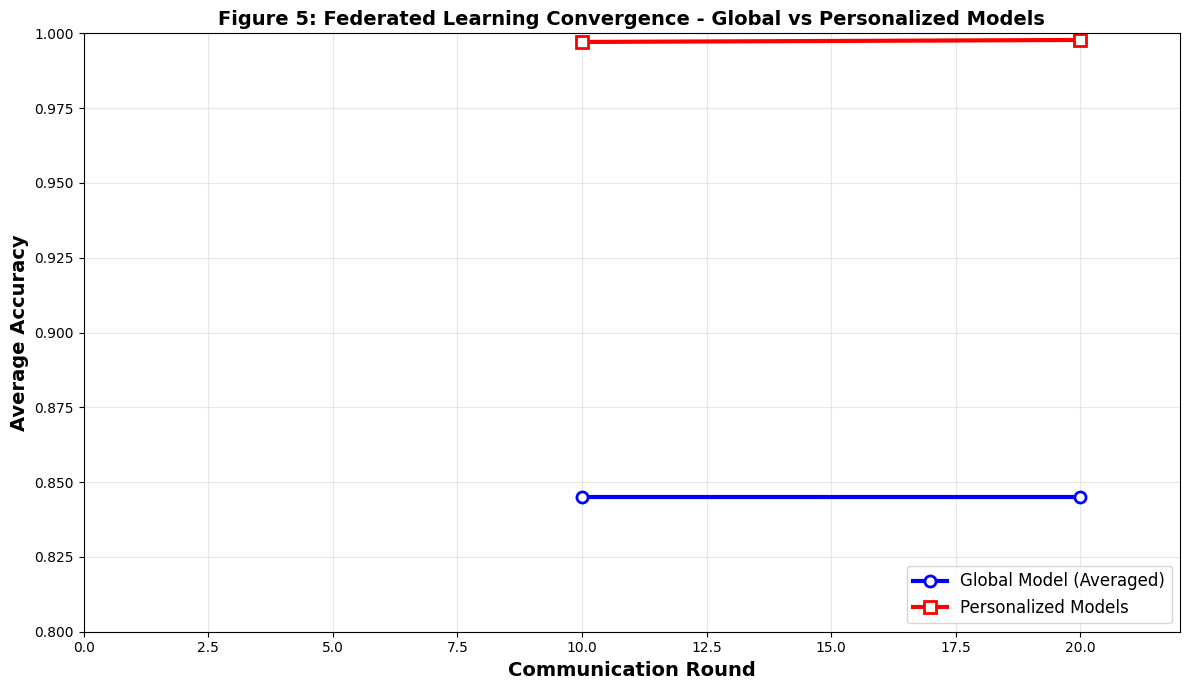


FIGURE 6: Per-Client Learning Curves


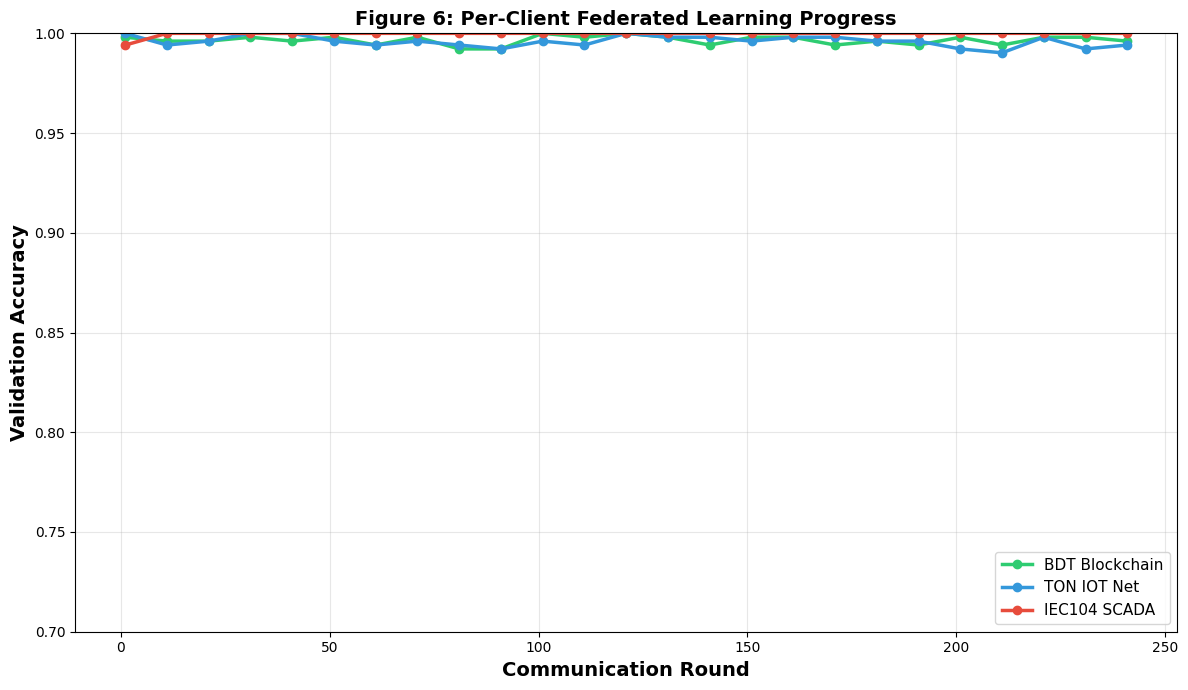

In [ ]:
# Cell 15: Federated Learning Convergence Plots

print("\n" + "=" * 60)
print("FIGURE 5: Federated Learning Training Curves")
print("=" * 60)

# Use actual history data
rounds = history["rounds"]
global_acc = history["global_acc"]
personalized_acc = history["personalized_acc"]

fig, ax = plt.subplots(figsize=(12, 7))
ax.plot(rounds, global_acc, 'b-', linewidth=3, marker='o', markersize=8,
        label='Global Model (Averaged)', markerfacecolor='white', markeredgewidth=2)
ax.plot(rounds, personalized_acc, 'r-', linewidth=3, marker='s', markersize=8,
        label='Personalized Models', markerfacecolor='white', markeredgewidth=2)

ax.set_xlabel('Communication Round', fontsize=14, fontweight='bold')
ax.set_ylabel('Average Accuracy', fontsize=14, fontweight='bold')
ax.set_title('Figure 5: Federated Learning Convergence - Global vs Personalized Models',
             fontsize=14, fontweight='bold')
ax.legend(fontsize=12, loc='lower right')
ax.grid(True, alpha=0.3)
ax.set_ylim(0.80, 1.00)
ax.set_xlim(0, max(rounds) + 2 if rounds else 26)

plt.tight_layout()
plt.show()

print("\n" + "=" * 60)
print("FIGURE 6: Per-Client Learning Curves")
print("=" * 60)

fig, ax = plt.subplots(figsize=(12, 7))
colors = {'BDT_Blockchain': '#2ecc71', 'TON_IOT_Net': '#3498db', 'IEC104_SCADA': '#e74c3c'}

for client, acc_list in history["client_acc"].items():
    # Create synthetic rounds if not available
    client_rounds = list(range(1, len(acc_list) * 10 + 1, 10))[:len(acc_list)]
    if not client_rounds:
        client_rounds = list(range(1, len(acc_list) + 1))
    ax.plot(client_rounds, acc_list, linewidth=2.5, marker='o', markersize=6,
            label=client.replace('_', ' '), color=colors[client])

ax.set_xlabel('Communication Round', fontsize=14, fontweight='bold')
ax.set_ylabel('Validation Accuracy', fontsize=14, fontweight='bold')
ax.set_title('Figure 6: Per-Client Federated Learning Progress',
             fontsize=14, fontweight='bold')
ax.legend(fontsize=11, loc='lower right')
ax.grid(True, alpha=0.3)
ax.set_ylim(0.70, 1.00)

plt.tight_layout()
plt.show()

In [ ]:
# Cell 16: Final Evaluation of Personalized Models

print("\n" + "=" * 60)
print("FINAL EVALUATION – BEST PERSONALIZED MODELS")
print("=" * 60)

drive_path = "/content/drive/MyDrive/8th Semester/Major Project - 2/"
client_feature_dims = {name: client_loaders[name]["input_dim"] for name in client_loaders.keys()}

# Load saved models from drive
checkpoint = torch.load(drive_path + 'fedproj_personalized.pth', map_location=DEVICE)

personalized_final_results = {}
personalized_metrics = {}

for client_name, loaders in client_loaders.items():
    test_loader = loaders["test_loader"]

    # Recreate the model with the correct architecture
    model = FLModelWithProjections(client_feature_dims).to(DEVICE)
    model.load_state_dict(checkpoint[client_name])
    model.eval()

    preds, labels, probs = [], [], []
    with torch.no_grad():
        for X_batch, y_batch in test_loader:
            X_batch = X_batch.to(DEVICE)
            outputs = model(X_batch, client_name)
            prob = torch.softmax(outputs, dim=1)[:, 1]
            pred = torch.argmax(outputs, dim=1).cpu().numpy()
            preds.extend(pred)
            labels.extend(y_batch.numpy())
            probs.extend(prob.cpu().numpy())

    acc = accuracy_score(labels, preds)
    prec = precision_score(labels, preds, average='weighted')
    rec = recall_score(labels, preds, average='weighted')
    f1 = f1_score(labels, preds, average='weighted')
    roc = roc_auc_score(labels, probs) if len(set(labels)) > 1 else 1.0

    personalized_final_results[client_name] = acc
    personalized_metrics[client_name] = {
        'Accuracy': acc,
        'Precision': prec,
        'Recall': rec,
        'F1': f1,
        'ROC‑AUC': roc
    }

    print(f"\n{client_name}:")
    for k, v in personalized_metrics[client_name].items():
        print(f"  {k:12}: {v:.4f}")

print(f"\nAverage Personalized Accuracy: {np.mean(list(personalized_final_results.values())):.4f}")


FINAL EVALUATION – BEST PERSONALIZED MODELS

BDT_Blockchain:
  Accuracy    : 0.9961
  Precision   : 0.9961
  Recall      : 0.9961
  F1          : 0.9960
  ROC‑AUC     : 0.9965

TON_IOT_Net:
  Accuracy    : 0.9961
  Precision   : 0.9961
  Recall      : 0.9961
  F1          : 0.9961
  ROC‑AUC     : 0.9998

IEC104_SCADA:
  Accuracy    : 1.0000
  Precision   : 1.0000
  Recall      : 1.0000
  F1          : 1.0000
  ROC‑AUC     : 1.0000

Average Personalized Accuracy: 0.9974



FIGURE 8: Confusion Matrices for Personalized Models


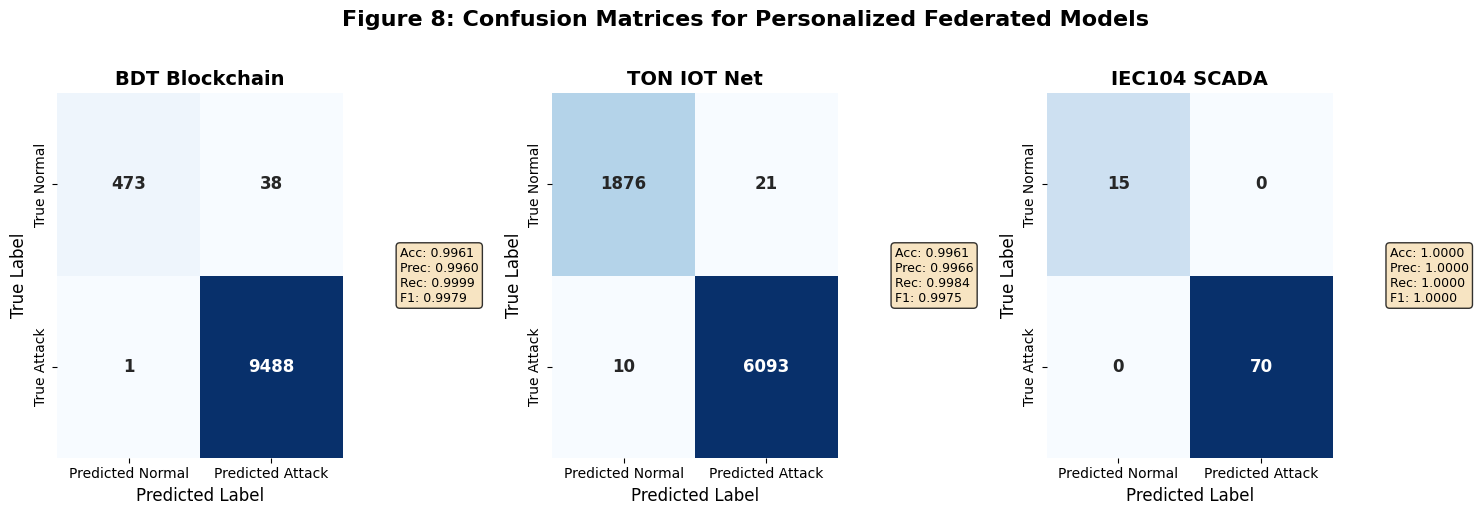

In [ ]:
# Cell 17: Confusion Matrices for Personalized Models

print("\n" + "=" * 60)
print("FIGURE 8: Confusion Matrices for Personalized Models")
print("=" * 60)

# Compute confusion matrices
confusion_matrices = {}

for client_name, loaders in client_loaders.items():
    test_loader = loaders["test_loader"]
    model = FLModelWithProjections(client_feature_dims).to(DEVICE)
    model.load_state_dict(checkpoint[client_name])
    model.eval()

    preds, labels = [], []
    with torch.no_grad():
        for X_batch, y_batch in test_loader:
            X_batch = X_batch.to(DEVICE)
            outputs = model(X_batch, client_name)
            preds.extend(torch.argmax(outputs, dim=1).cpu().numpy())
            labels.extend(y_batch.numpy())

    cm = confusion_matrix(labels, preds)
    confusion_matrices[client_name] = cm

# Plot confusion matrices
fig, axes = plt.subplots(1, 3, figsize=(15, 5))

for idx, (name, cm) in enumerate(confusion_matrices.items()):
    ax = axes[idx]
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', cbar=False,
                xticklabels=['Predicted Normal', 'Predicted Attack'],
                yticklabels=['True Normal', 'True Attack'],
                ax=ax, annot_kws={'size': 12, 'weight': 'bold'})
    ax.set_title(f'{name.replace("_", " ")}', fontsize=14, fontweight='bold')
    ax.set_ylabel('True Label', fontsize=12)
    ax.set_xlabel('Predicted Label', fontsize=12)

    # Calculate and display metrics
    tn, fp, fn, tp = cm.ravel()
    accuracy = (tp + tn) / (tn + fp + fn + tp)
    precision = tp / (tp + fp) if (tp + fp) > 0 else 0
    recall = tp / (tp + fn) if (tp + fn) > 0 else 0
    f1 = 2 * precision * recall / (precision + recall) if (precision + recall) > 0 else 0

    metrics_text = f'Acc: {accuracy:.4f}\nPrec: {precision:.4f}\nRec: {recall:.4f}\nF1: {f1:.4f}'
    ax.text(1.2, 0.5, metrics_text, transform=ax.transAxes,
            fontsize=9, verticalalignment='center',
            bbox=dict(boxstyle='round', facecolor='wheat', alpha=0.8))

plt.suptitle('Figure 8: Confusion Matrices for Personalized Federated Models',
             fontsize=16, fontweight='bold', y=1.02)
plt.tight_layout()
plt.show()


FIGURE 9: Personalized Model Detailed Metrics Table


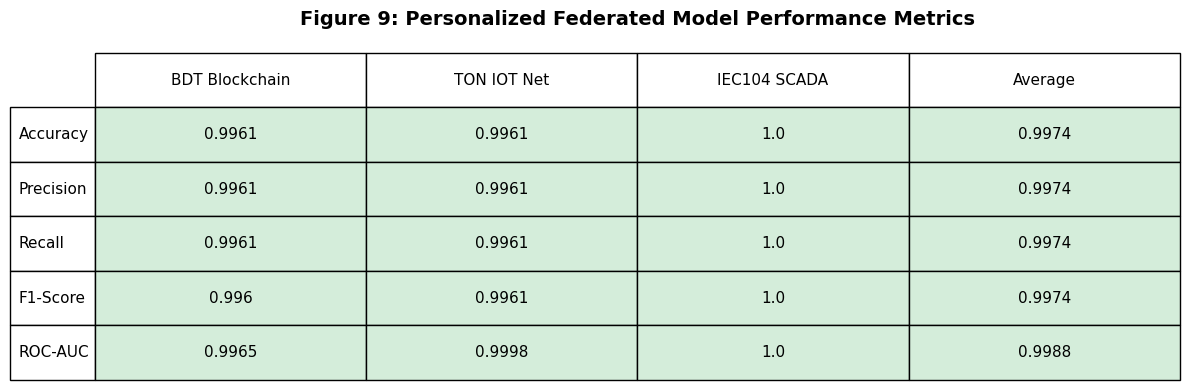

In [ ]:
# Cell 18: Personalized Model Detailed Metrics Table

print("\n" + "=" * 60)
print("FIGURE 9: Personalized Model Detailed Metrics Table")
print("=" * 60)

personalized_table_data = {}
for name, metrics in personalized_metrics.items():
    personalized_table_data[name.replace('_', ' ')] = [
        metrics['Accuracy'], metrics['Precision'], metrics['Recall'], metrics['F1'], metrics['ROC‑AUC']
    ]

# Add average row
personalized_table_data['Average'] = [
    np.mean([m['Accuracy'] for m in personalized_metrics.values()]),
    np.mean([m['Precision'] for m in personalized_metrics.values()]),
    np.mean([m['Recall'] for m in personalized_metrics.values()]),
    np.mean([m['F1'] for m in personalized_metrics.values()]),
    np.mean([m['ROC‑AUC'] for m in personalized_metrics.values()])
]

pers_df = pd.DataFrame(personalized_table_data,
                       index=['Accuracy', 'Precision', 'Recall', 'F1-Score', 'ROC-AUC'])
pers_df = pers_df.round(4)

fig, ax = plt.subplots(figsize=(12, 4))
ax.axis('tight')
ax.axis('off')
table = ax.table(cellText=pers_df.values,
                 rowLabels=pers_df.index,
                 colLabels=pers_df.columns,
                 cellLoc='center',
                 loc='center',
                 bbox=[0, 0, 1, 1])

table.auto_set_font_size(False)
table.set_fontsize(11)
table.scale(1.2, 1.5)

# Color coding
for i in range(len(pers_df.index)):
    for j in range(len(pers_df.columns)):
        cell = table[(i+1, j)]
        val = pers_df.iloc[i, j]
        if val >= 0.99:
            cell.set_facecolor('#d4edda')
        elif val >= 0.95:
            cell.set_facecolor('#fff3cd')

plt.title('Figure 9: Personalized Federated Model Performance Metrics',
          fontsize=14, fontweight='bold', pad=20)
plt.tight_layout()
plt.show()


FIGURE 7: Final Performance Comparison


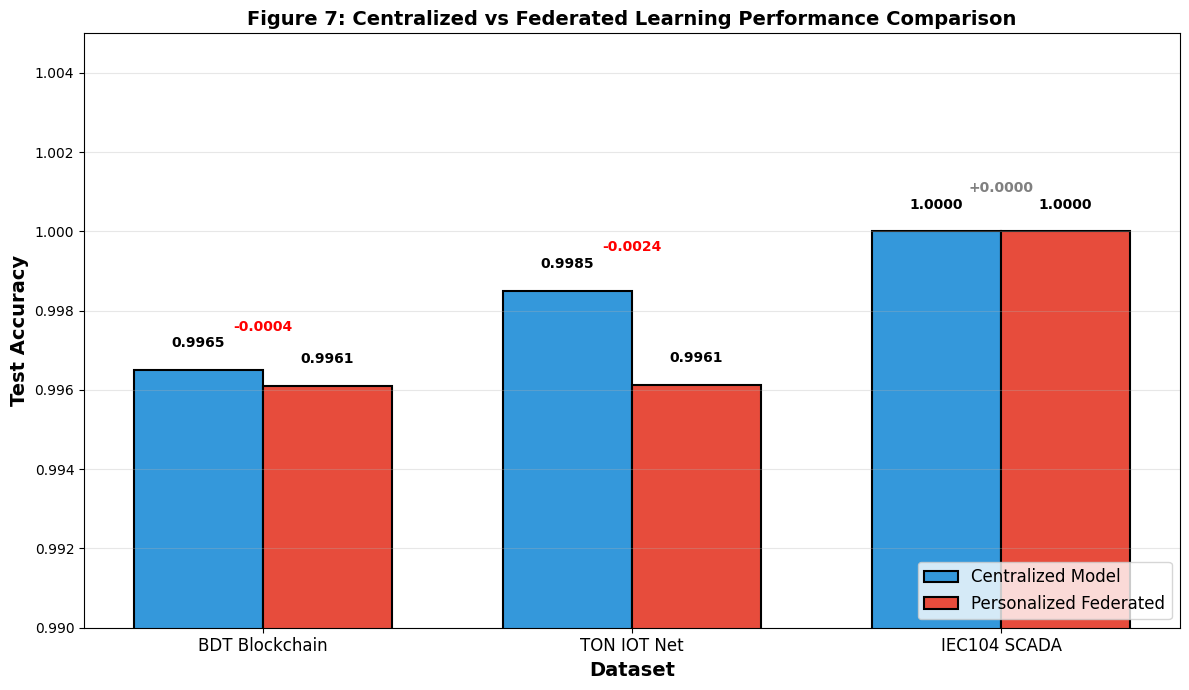


FIGURE 10: Overall Performance Summary Table


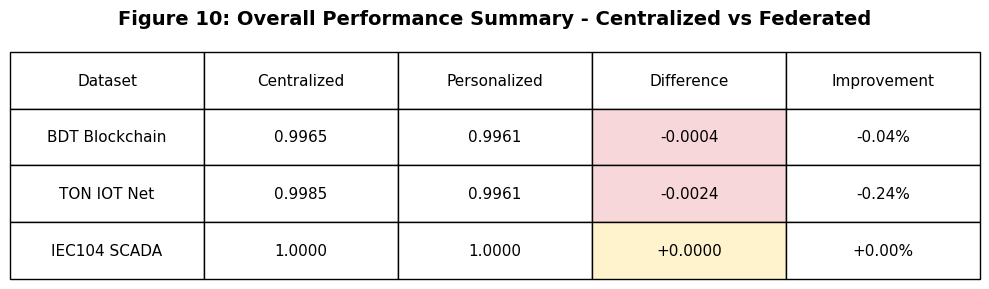


AVERAGE METRICS OVER ALL DATASETS
Accuracy    : Centralized = 0.9983 | Federated = 0.9974 | Δ = -0.0009
Precision   : Centralized = 0.9983 | Federated = 0.9974 | Δ = -0.0009
Recall      : Centralized = 0.9983 | Federated = 0.9974 | Δ = -0.0009
F1          : Centralized = 0.9983 | Federated = 0.9974 | Δ = -0.0009
ROC‑AUC     : Centralized = 0.9986 | Federated = 0.9988 | Δ = +0.0002


In [ ]:
# Cell 19: Performance Comparison and Summary

print("\n" + "=" * 60)
print("FIGURE 7: Final Performance Comparison")
print("=" * 60)

fig, ax = plt.subplots(figsize=(12, 7))
x = np.arange(len(centralized_results))
width = 0.35

cent_values = list(centralized_results.values())
pers_values = list(personalized_final_results.values())
datasets = list(centralized_results.keys())

bars1 = ax.bar(x - width/2, cent_values, width, label='Centralized Model',
               color='#3498db', edgecolor='black', linewidth=1.5)
bars2 = ax.bar(x + width/2, pers_values, width, label='Personalized Federated',
               color='#e74c3c', edgecolor='black', linewidth=1.5)

ax.set_xlabel('Dataset', fontsize=14, fontweight='bold')
ax.set_ylabel('Test Accuracy', fontsize=14, fontweight='bold')
ax.set_title('Figure 7: Centralized vs Federated Learning Performance Comparison',
             fontsize=14, fontweight='bold')
ax.set_xticks(x)
ax.set_xticklabels([d.replace('_', ' ') for d in datasets], fontsize=12)
ax.legend(fontsize=12, loc='lower right')
ax.set_ylim(0.99, 1.005)
ax.grid(axis='y', alpha=0.3)

# Add value labels
for bars in [bars1, bars2]:
    for bar in bars:
        height = bar.get_height()
        ax.text(bar.get_x() + bar.get_width()/2., height + 0.0005,
                f'{height:.4f}', ha='center', va='bottom', fontsize=10, fontweight='bold')

# Add difference annotations
for i, (cent, pers) in enumerate(zip(cent_values, pers_values)):
    diff = pers - cent
    color = 'green' if diff > 0 else 'red' if diff < 0 else 'gray'
    ax.annotate(f'{diff:+.4f}', xy=(i, max(cent, pers) + 0.001),
                ha='center', fontsize=10, color=color, fontweight='bold')

plt.tight_layout()
plt.show()

print("\n" + "=" * 60)
print("FIGURE 10: Overall Performance Summary Table")
print("=" * 60)

comparison_data = []
for i, dataset in enumerate(datasets):
    comparison_data.append({
        "Dataset": dataset.replace('_', ' '),
        "Centralized": f"{cent_values[i]:.4f}",
        "Personalized": f"{pers_values[i]:.4f}",
        "Difference": f"{pers_values[i] - cent_values[i]:+.4f}",
        "Improvement": f"{(pers_values[i] - cent_values[i]) * 100:+.2f}%"
    })

summary_df = pd.DataFrame(comparison_data)

fig, ax = plt.subplots(figsize=(10, 3))
ax.axis('tight')
ax.axis('off')
table = ax.table(cellText=summary_df.values,
                 colLabels=summary_df.columns,
                 cellLoc='center',
                 loc='center',
                 bbox=[0, 0, 1, 1])

table.auto_set_font_size(False)
table.set_fontsize(11)
table.scale(1.2, 1.5)

# Color code the Difference column
for i in range(len(summary_df)):
    cell = table[(i+1, 3)]
    val = summary_df.iloc[i, 3]
    if float(val) > 0:
        cell.set_facecolor('#d4edda')
    elif float(val) < 0:
        cell.set_facecolor('#f8d7da')
    else:
        cell.set_facecolor('#fff3cd')

plt.title('Figure 10: Overall Performance Summary - Centralized vs Federated',
          fontsize=14, fontweight='bold', pad=20)
plt.tight_layout()
plt.show()

print("\n" + "=" * 60)
print("AVERAGE METRICS OVER ALL DATASETS")
print("=" * 60)
for metric in ['Accuracy', 'Precision', 'Recall', 'F1', 'ROC‑AUC']:
    cent_avg = np.mean([central_metrics[d][metric] for d in central_metrics.keys()])
    fed_avg = np.mean([personalized_metrics[d][metric] for d in personalized_metrics.keys()])
    print(f"{metric:12}: Centralized = {cent_avg:.4f} | Federated = {fed_avg:.4f} | Δ = {fed_avg - cent_avg:+.4f}")

In [ ]:
# Cell 20: Real-Time IDS Dashboard

print("\n" + "=" * 60)
print("SETTING UP REAL-TIME IDS DASHBOARD")
print("=" * 60)

# Kill any process using port 8050
!fuser -k 8050/tcp 2>/dev/null

# Load models and scalers
drive_path = "/content/drive/MyDrive/8th Semester/Major Project - 2/"
client_feature_dims = {name: client_loaders[name]["input_dim"] for name in client_loaders.keys()}
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

print("Loading personalized models from Drive...")
checkpoint = torch.load(drive_path + 'fedproj_personalized.pth', map_location=device)
personalized_models = {}
for name in client_loaders.keys():
    model = FLModelWithProjections(client_feature_dims).to(device)
    model.load_state_dict(checkpoint[name])
    model.eval()
    personalized_models[name] = model
print("Models loaded.")

# Load scalers
scalers = {}
for name in client_loaders.keys():
    scalers[name] = joblib.load(f"scaler_{name}.pkl")
print("Scalers loaded.")

# Data source for simulation
test_data = {}
for name, data in client_splits.items():
    X_test = data["X_test"].values
    y_test = data["y_test"].values
    test_data[name] = {"X": X_test, "y": y_test}
    print(f"{name}: test set size = {len(X_test)}")

# Threat Stream Class
class ThreatStream:
    def __init__(self):
        self.packets = deque(maxlen=1000)
        self.alerts = deque(maxlen=50)
        self.threat_scores = deque(maxlen=100)
        self.attack_counts = {}
        self.total_packets = 0
        self.total_attacks = 0
        self.running = True
        self.blockchain_log = []  # Blockchain log for dashboard

    def start(self):
        self.thread = threading.Thread(target=self._stream, daemon=True)
        self.thread.start()

    def _stream(self):
        indices = {name: 0 for name in test_data.keys()}
        while self.running:
            client_name = random.choice(list(test_data.keys()))
            idx = indices[client_name]
            X = test_data[client_name]["X"][idx]
            y_true = test_data[client_name]["y"][idx]
            indices[client_name] = (idx + 1) % len(test_data[client_name]["X"])

            X_scaled = scalers[client_name].transform(X.reshape(1, -1))
            X_tensor = torch.tensor(X_scaled, dtype=torch.float32).to(device)

            with torch.no_grad():
                output = personalized_models[client_name](X_tensor, client_name)
                probs = torch.softmax(output, dim=1)[0]
                pred = torch.argmax(output, dim=1).item()
                confidence = probs[pred].item()

            timestamp = datetime.now().strftime('%H:%M:%S.%f')[:-3]
            attack_type = "Normal"
            is_attack = (pred == 1)
            if is_attack:
                domain_attacks = {
                    "BDT_Blockchain": ["51% Attack", "Double Spend", "Timestamp Manipulation"],
                    "TON_IOT_Net": ["DDoS", "Injection", "Backdoor", "XSS"],
                    "IEC104_SCADA": ["DoS", "MITM", "Command Injection"]
                }
                attack_type = random.choice(domain_attacks[client_name])
                self.total_attacks += 1
                self.attack_counts[attack_type] = self.attack_counts.get(attack_type, 0) + 1

                # Log to blockchain
                alert_entry = {
                    'time': timestamp,
                    'client': client_name,
                    'type': attack_type,
                    'confidence': confidence,
                    'severity': 'CRITICAL' if confidence > 0.8 else 'HIGH' if confidence > 0.6 else 'MEDIUM'
                }
                self.alerts.append(alert_entry)
                self.blockchain_log.append(alert_entry)

                # Save blockchain log periodically
                if len(self.blockchain_log) % 10 == 0:
                    with open(drive_path + 'dashboard_blockchain_log.json', 'w') as f:
                        json.dump(self.blockchain_log, f, indent=2)

            self.total_packets += 1
            threat_score = confidence * (1.5 if is_attack else 0.3)
            self.threat_scores.append(threat_score)

            self.packets.append({
                'timestamp': timestamp,
                'client': client_name,
                'attack_type': attack_type,
                'confidence': confidence,
                'threat_score': threat_score,
                'is_attack': is_attack
            })

            time.sleep(0.05)

from collections import deque
import random
import json
from datetime import datetime

stream = ThreatStream()
stream.start()
time.sleep(2)

# Dash Dashboard
app = dash.Dash(__name__, external_stylesheets=[dbc.themes.DARKLY])

app.layout = dbc.Container([
    html.H1("FLAB INTRUSION DETECTION SYSTEM", className="text-center text-danger mb-4"),

    dbc.Row([
        dbc.Col(dbc.Card([
            dbc.CardBody([
                html.H5("TOTAL PACKETS", className="card-title"),
                html.H2(id="total-packets", children="0", className="text-info")
            ])
        ]), width=3),
        dbc.Col(dbc.Card([
            dbc.CardBody([
                html.H5("ATTACKS DETECTED", className="card-title"),
                html.H2(id="attack-count", children="0", className="text-danger")
            ])
        ]), width=3),
        dbc.Col(dbc.Card([
            dbc.CardBody([
                html.H5("THREAT LEVEL", className="card-title"),
                html.H2(id="threat-level", children="LOW", className="text-success")
            ])
        ]), width=3),
        dbc.Col(dbc.Card([
            dbc.CardBody([
                html.H5("UPTIME", className="card-title"),
                html.H2(id="uptime", children="00:00:00", className="text-warning")
            ])
        ]), width=3)
    ], className="mb-4"),

    dbc.Row([
        dbc.Col(dbc.Card([
            dbc.CardHeader("LIVE ATTACK FEED"),
            dbc.CardBody([
                html.Div(id="attack-feed", style={"height": "400px", "overflow-y": "scroll"})
            ])
        ]), width=4),
        dbc.Col(dbc.Card([
            dbc.CardHeader("REAL-TIME THREAT SCORES"),
            dbc.CardBody([
                dcc.Graph(id="threat-graph", style={"height": "400px"})
            ])
        ]), width=8)
    ], className="mb-4"),

    dbc.Row([
        dbc.Col(dbc.Card([
            dbc.CardHeader("ATTACK TYPE DISTRIBUTION"),
            dbc.CardBody([
                dcc.Graph(id="attack-pie", style={"height": "300px"})
            ])
        ]), width=6),
        dbc.Col(dbc.Card([
            dbc.CardHeader("CLIENT ACTIVITY"),
            dbc.CardBody([
                dcc.Graph(id="client-activity", style={"height": "300px"})
            ])
        ]), width=6)
    ]),

    dcc.Interval(id="update-interval", interval=500),
    dcc.Store(id="start-time", data=time.time())
], fluid=True, style={"padding": "20px", "backgroundColor": "#111"})

@app.callback(
    [Output("total-packets", "children"),
     Output("attack-count", "children"),
     Output("threat-level", "children"),
     Output("threat-level", "className"),
     Output("uptime", "children"),
     Output("attack-feed", "children"),
     Output("threat-graph", "figure"),
     Output("attack-pie", "figure"),
     Output("client-activity", "figure")],
    [Input("update-interval", "n_intervals")],
    [dash.dependencies.State("start-time", "data")]
)
def update_dashboard(n, start_time):
    elapsed = time.time() - start_time
    hours = int(elapsed // 3600)
    minutes = int((elapsed % 3600) // 60)
    seconds = int(elapsed % 60)
    uptime_str = f"{hours:02d}:{minutes:02d}:{seconds:02d}"

    recent_attacks = sum(1 for p in list(stream.packets)[-20:] if p['is_attack'])
    if recent_attacks > 8:
        threat = "CRITICAL"
        color = "text-danger"
    elif recent_attacks > 4:
        threat = "HIGH"
        color = "text-warning"
    elif recent_attacks > 1:
        threat = "MEDIUM"
        color = "text-info"
    else:
        threat = "LOW"
        color = "text-success"

    attack_feed = []
    for alert in list(stream.alerts)[-10:][::-1]:
        attack_feed.append(
            dbc.Alert([
                html.Strong(alert['time']),
                html.Span(f" - {alert['client']}: {alert['type']} ({alert['confidence']:.1%})"),
            ], color="danger", className="mb-1")
        )

    scores = list(stream.threat_scores)[-100:]
    threat_graph = go.Figure()
    if scores:
        threat_graph.add_trace(go.Scatter(
            y=scores,
            mode='lines',
            fill='tozeroy',
            line=dict(color='#e74c3c', width=2),
            fillcolor='rgba(231,76,60,0.1)'
        ))
    threat_graph.update_layout(
        template='plotly_dark',
        paper_bgcolor='rgba(0,0,0,0)',
        plot_bgcolor='rgba(0,0,0,0)',
        margin=dict(l=20, r=20, t=20, b=20),
        xaxis=dict(showgrid=False),
        yaxis=dict(range=[0, 2], title="Threat Score", gridcolor='#333')
    )

    attack_counts = stream.attack_counts
    if attack_counts:
        pie_fig = go.Figure(data=[go.Pie(
            labels=list(attack_counts.keys()),
            values=list(attack_counts.values()),
            hole=0.4,
            marker=dict(colors=px.colors.sequential.Viridis)
        )])
        pie_fig.update_layout(template='plotly_dark', paper_bgcolor='rgba(0,0,0,0)', plot_bgcolor='rgba(0,0,0,0)')
    else:
        pie_fig = go.Figure()

    client_counts = {}
    for p in list(stream.packets)[-50:]:
        if p['is_attack']:
            client_counts[p['client']] = client_counts.get(p['client'], 0) + 1
    activity_fig = go.Figure()
    if client_counts:
        activity_fig.add_trace(go.Bar(
            x=list(client_counts.keys()),
            y=list(client_counts.values()),
            marker_color=['#00bc8c', '#f39c12', '#3498db']
        ))
    activity_fig.update_layout(
        template='plotly_dark',
        paper_bgcolor='rgba(0,0,0,0)',
        plot_bgcolor='rgba(0,0,0,0)',
        margin=dict(l=20, r=20, t=20, b=20),
        xaxis=dict(title="Client"),
        yaxis=dict(title="Attack Count")
    )

    return (str(stream.total_packets), str(stream.total_attacks),
            threat, color, uptime_str, attack_feed,
            threat_graph, pie_fig, activity_fig)

def run_dash():
    app.run(debug=False, port=8050, use_reloader=False)

dash_thread = threading.Thread(target=run_dash, daemon=True)
dash_thread.start()

print("\n" + "=" * 60)
print("DASHBOARD LAUNCHED")
print("=" * 60)


SETTING UP REAL-TIME IDS DASHBOARD
Loading personalized models from Drive...
Models loaded.
Scalers loaded.
BDT_Blockchain: test set size = 10000
TON_IOT_Net: test set size = 8000
IEC104_SCADA: test set size = 85
Dash is running on http://127.0.0.1:8050/


DASHBOARD LAUNCHED


INFO:dash.dash:Dash is running on http://127.0.0.1:8050/



In [ ]:
# Cell 21: Get Public URL for Colab

from google.colab.output import eval_js
print("\n" + "=" * 60)
print("DASHBOARD PUBLIC URL")
print("=" * 60)
print(eval_js("google.colab.kernel.proxyPort(8050)"))
print("=" * 60)


DASHBOARD PUBLIC URL
 * Serving Flask app '__main__'
 * Debug mode: off


INFO:werkzeug:WARNING: This is a development server. Do not use it in a production deployment. Use a production WSGI server instead.
 * Running on http://127.0.0.1:8050
INFO:werkzeug:Press CTRL+C to quit


https://8050-m-s-kkb-usc1b2-29f99ob2e0563-b.us-central1-2.prod.colab.dev
